 This dataset was independently compiled through manual research of publicly available real estate listings. It represents real-world housing data from multiple well-known residential areas in Karachi. The selected features — Area (sqft), Number of Bedrooms, Number of Bathrooms, Location, Furnishing status and, Price — were chosen to capture the most influential factors affecting property valuation in the local housing market. This dataset was created specifically for the purpose of developing and evaluating machine learning models for house price prediction.


In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import pickle


In [84]:

df = pd.read_csv("/content/House_prices.csv")
df = df.dropna(axis=1, how='all')
df.head()

,property type,bedrooms,bathrooms,area sqft,location,price,furnishing_status
0,House,3,3,1368,Bahria Town,16500000,Furnished
1,House,2,2,1800,DHA City,6200000,Furnished
2,House,5,5,4500,Bahria Town,48400000,Furnished
3,House,3,3,2448,Bahria Town,35000000,Furnished
4,House,5,5,4500,DHA City,100000000,Furnished


##EDA(Exploratory Data Analysis)

In [85]:
# Basic info: types, missing values
print(df.info())

# Summary stats for numeric columns
print(df.describe())

#checking info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   property type      189 non-null    object
 1   bedrooms           189 non-null    int64 
 2   bathrooms          189 non-null    int64 
 3   area sqft          189 non-null    int64 
 4   location           189 non-null    object
 5   price              189 non-null    int64 
 6   furnishing_status  189 non-null    object
dtypes: int64(4), object(3)
memory usage: 10.5+ KB
None
         bedrooms   bathrooms     area sqft         price
count  189.000000  189.000000    189.000000  1.890000e+02
mean     3.904762    4.031746   2977.671958  5.072513e+07
std      1.732489    1.685056   6838.116450  8.265002e+07
min      1.000000    1.000000    390.000000  6.500000e+05
25%      3.000000    3.000000   1080.000000  1.050000e+07
50%      3.000000    4.000000   1863.000000  2.650000e+07
75%      5.

The dataset contains 189 real estate listings with the following features: property type, bedrooms, bathrooms, area (sqft), location, furnishing status, and price.

Numerical features (bedrooms, bathrooms, area, price) show substantial variability:

Bedrooms range from 1 to 10, with a mean of ~3.9.

Bathrooms range from 1 to 7, averaging ~4.0.

Area varies widely from 390 sqft up to 90,000 sqft, with a median around 1,863 sqft.

Prices span from 650,000 to 900,000,000, with a median price of 26.5 million.

Categorical features include property type, location, and furnishing status, all fully populated.

Overall, the dataset is well-structured and suitable for predictive modeling, though preprocessing may include handling the wide range of area and price values (potential outliers) and encoding categorical features.

In [86]:
# Count missing values in each column
print(df.isnull().sum())

property type        0
bedrooms             0
bathrooms            0
area sqft            0
location             0
price                0
furnishing_status    0
dtype: int64


In [87]:
# List of unique locations
print("locations:", df['location'].unique())
print("property type:",df['property type'].unique())

locations: ['Bahria Town' 'DHA City' 'North Karachi' 'Gulshan-e-Maymar'
 'Gulshan-e-Iqbal' 'Malir Cantt']
property type: ['House' 'Flat']


/tmp/ipykernel_1256/3954359011.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


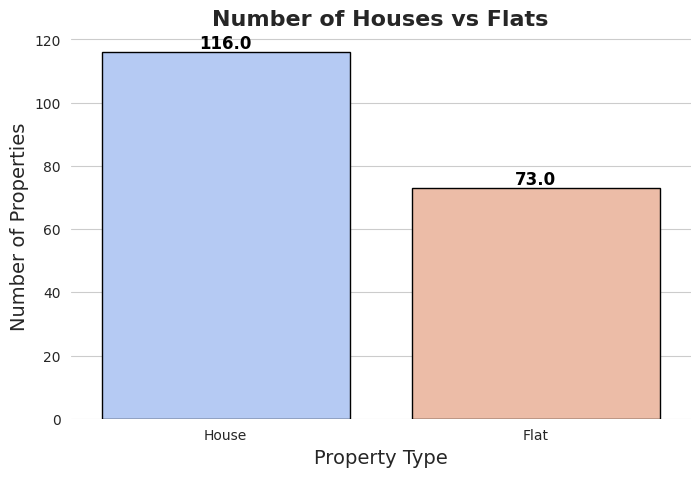

<Figure size 640x480 with 0 Axes>

In [88]:
# Simple bar chart for Houses vs Flats
# Set a nice style
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

# Create countplot with gradient colors
ax = sns.countplot(
    x='property type',
    data=df,
    palette=sns.color_palette("coolwarm", df['property type'].nunique()),
    edgecolor='black'
)

# Add annotations on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

# Titles and labels with bigger font
plt.title('Number of Houses vs Flats', fontsize=16, fontweight='bold')
plt.xlabel('Property Type', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)

# Remove unnecessary spines
sns.despine(left=True, bottom=True)

plt.show()


plt.savefig("houses_vs_flats")

/tmp/ipykernel_1256/2873048762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


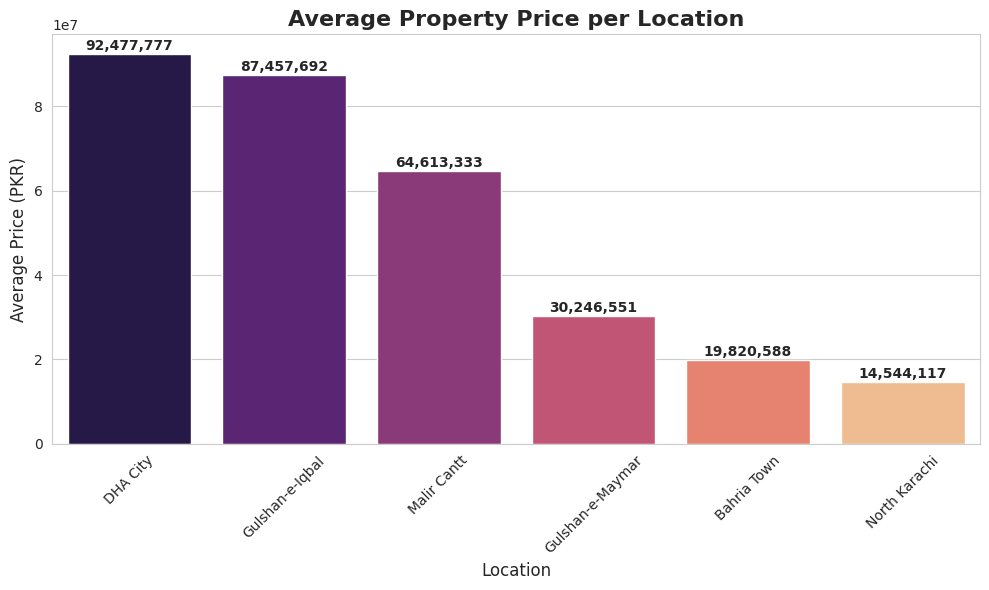

<Figure size 640x480 with 0 Axes>

In [89]:
# Calculate average price per location
avg_price_location = df.groupby('location')['price'].mean().sort_values(ascending=False)
# Plot
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")  # cleaner background
barplot = sns.barplot(
    x=avg_price_location.index,
    y=avg_price_location.values,
    palette='magma'  # vibrant, appealing palette
)

# Add title and labels
plt.title('Average Property Price per Location', fontsize=16, weight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Average Price (PKR)', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add value labels on top of each bar
for index, value in enumerate(avg_price_location.values):
    barplot.text(index, value + 1e6, f'{int(value):,}', ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()
plt.savefig("barplot")

## Location-Based Real Estate Insights for Karachi

1. **DHA City Karachi**  
   DHA City is Pakistan's first smart and sustainable city, offering top-tier infrastructure, high-end amenities, and prime, secure real estate. Its strategic location on the M-9 motorway, close to the city center, along with strict security, makes it a **premium, high-appreciation investment hub**. The area has limited commercialization compared to older, more central areas.

2. **Gulshan-e-Iqbal**  
   Located in Karachi East, Gulshan-e-Iqbal is the largest and most popular middle-to-upper-middle-class residential area. It offers a wide range of budget-friendly to premium housing, making it a strong option for property investment. However, due to **high population density**, it can feel crowded and noisy.

3. **Malir Cantonment**  
   Malir Cantonment is a secure, well-planned, green gated community, providing a peaceful and high-quality lifestyle. Challenges include **groundwater scarcity** and **strict security checkpoints**, which may cause delays for visitors.

4. **Gulshan-e-Maymar**  
   This well-planned, family-friendly area is known for its **structured 13 phases, greenery, and proximity to the M-9 Motorway**. It offers a peaceful environment with lower pollution levels, but suffers from **distance from the city center, limited public transport, and relatively high consumer prices**.

5. **Bahria Town Karachi**  
   Bahria Town offers a modern, secure lifestyle with **top infrastructure, landscaped parks, and reliable utilities**. However, its reputation has declined due to **legal, financial, and operational crises between 2019–2025**, including accusations of illegal land acquisition and failure to deliver plots.

6. **North Karachi**  
   North Karachi caters mainly to low- and middle-income families, offering **affordable housing and proximity to industrial zones**. While the area has good community infrastructure, it suffers from **aging or declining infrastructure, congestion, and noise** due to dense population.

---

**Summary:** Prices in these areas are influenced by **infrastructure, security, location, population density, and local amenities**. Premium, planned communities like DHA City and Gulshan-e-Iqbal command higher prices, while older or more densely populated areas offer affordable options with trade-offs in convenience or space.

/tmp/ipykernel_1256/3331478682.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='property type', y='price', data=df, palette='Set2')


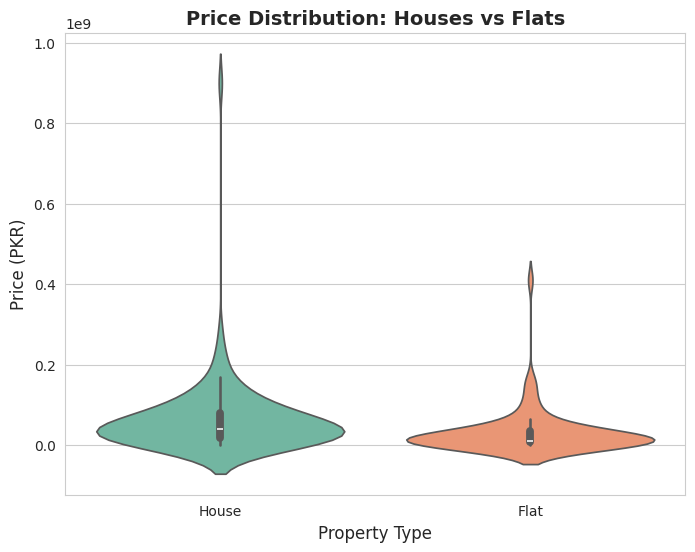

<Figure size 640x480 with 0 Axes>

In [90]:
plt.figure(figsize=(8,6))
sns.violinplot(x='property type', y='price', data=df, palette='Set2')
plt.title('Price Distribution: Houses vs Flats', fontsize=14, weight='bold')
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Price (PKR)', fontsize=12)
plt.show()
plt.savefig("voilin")

## Analysis Summary: Why Houses are More Expensive than Flats

In dataset of 189 real estate listings, we can observe that **houses generally have higher prices than flats**, even within the same locations. Several key factors contribute to this trend:

1. **Space**: Houses typically offer larger built-up areas and land plots compared to flats. This extra space naturally drives up the overall price.

2. **Privacy & Autonomy**: Unlike flats, houses provide private entrances, yards, and gardens. Buyers value this independence, which is reflected in the higher prices.

3. **Location & Scarcity**: Houses are often located in **premium neighborhoods** or exclusive gated communities. Limited availability in desirable areas increases demand and price.

4. **Amenities & Status**: Many houses include additional features like garages, private pools, or furnished interiors. They also carry a status factor that buyers are willing to pay for.

**Conclusion**: The combination of **larger space, greater privacy, prime locations, and premium amenities** makes houses more expensive than flats in most real estate markets. This insight is crucial when analyzing pricing trends or building predictive models for property prices.

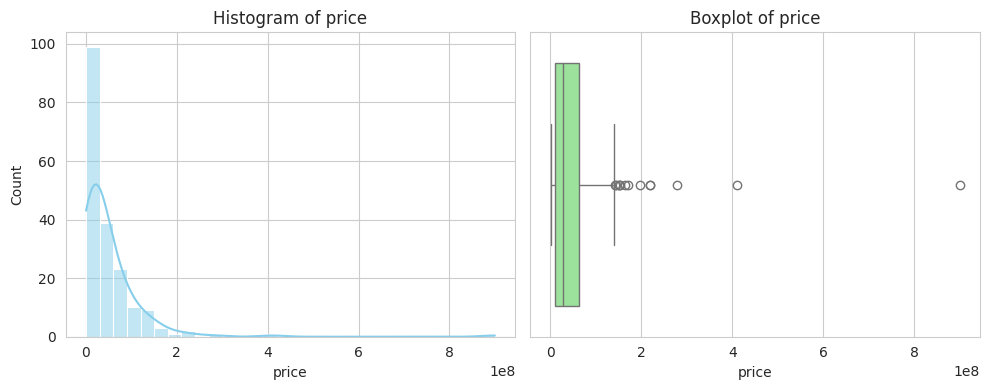

<Figure size 640x480 with 0 Axes>

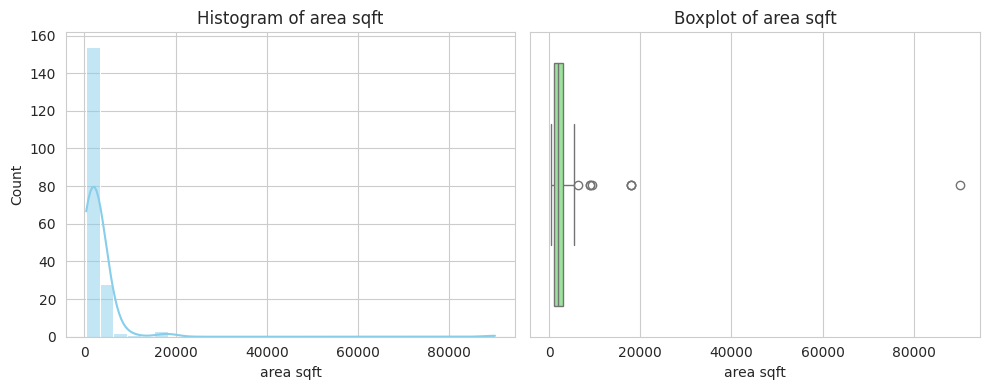

<Figure size 640x480 with 0 Axes>

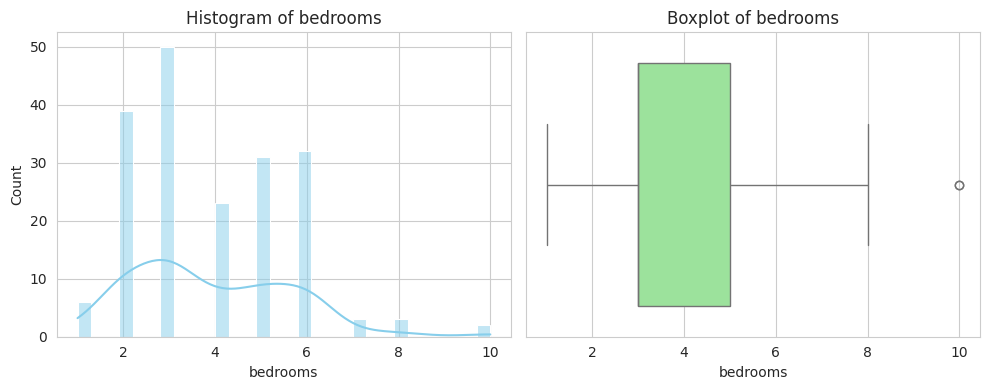

<Figure size 640x480 with 0 Axes>

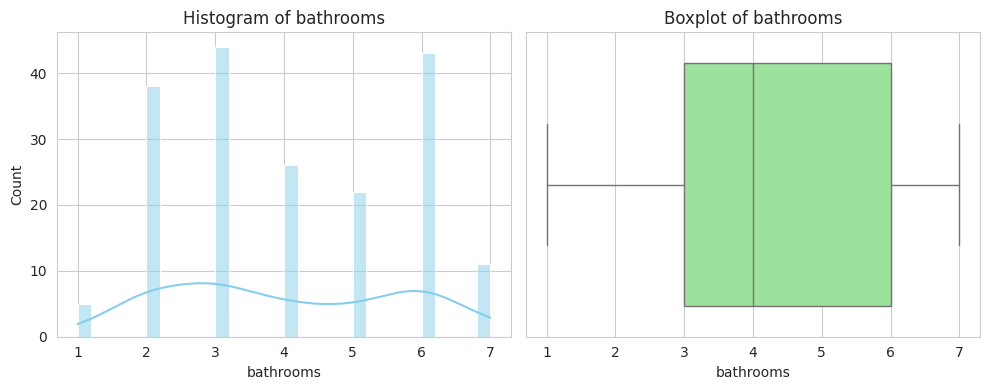

<Figure size 640x480 with 0 Axes>

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set_style("whitegrid")

numerical_features = ['price', 'area sqft', 'bedrooms', 'bathrooms']

for feature in numerical_features:
    plt.figure(figsize=(10,4))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {feature}')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[feature], color='lightgreen')
    plt.title(f'Boxplot of {feature}')

    plt.tight_layout()
    plt.show()
    plt.savefig("pairplot1")

## Summary of Feature Distributions

**Price:**  
- Property prices are **highly diverse**, ranging from very low to extremely high values.  
- This is mainly due to differences between **flats and houses**, with houses generally costing more.  
- Certain locations, such as **DHA City**, are premium areas and push prices higher.  
- The boxplot highlights **high-value outliers**, which may need special attention during modeling.  

**Area (sqft):**  
- Property areas show **right-skewed distributions**, with most homes in the mid-range but some very large houses creating outliers.  
- Differences between flats and houses explain this spread, and locations with larger plots, like DHA or Malir Cantonment, contribute to higher area values.  

**Bedrooms & Bathrooms:**  
- Most properties have **around 5-6 bedrooms and bathrooms**, but some houses have significantly more.  
- These counts vary based on property type and size, reflecting a mix of mid-sized flats and large houses in different locations.  

**Conclusion:**  
- Overall, property features show **diverse ranges and some extreme values**.  
- Differences in **property type and location** drive much of this variation, which should be considered when analyzing or modeling the data.

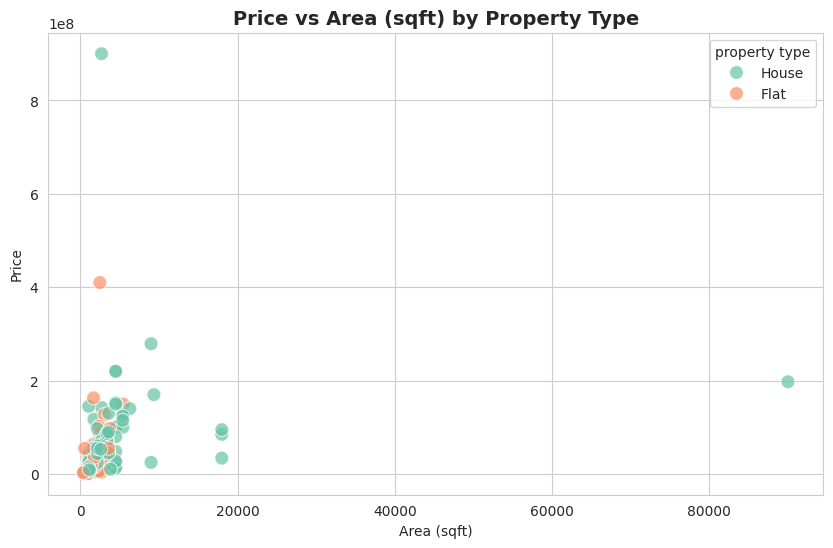

<Figure size 640x480 with 0 Axes>

In [92]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='area sqft', y='price', hue='property type', data=df, palette='Set2', s=100, alpha=0.7)
plt.title('Price vs Area (sqft) by Property Type', fontsize=14, fontweight='bold')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.show()
plt.savefig("area_Vs_price")

## Summary: Price vs Area

- In general, **houses occupy larger areas** compared to flats, which contributes to higher prices.  
- However, **price is not determined by area alone**. In Karachi's real estate market, **location plays a critical role**.  
- A property with a smaller area in a **premium neighborhood** like DHA City or Bahria Town can still command a **higher price** than a larger property in a less desirable area.  
- This highlights the **dual influence of property type and location** on pricing: while larger homes are usually more expensive, a smaller flat in a prime location can sometimes exceed the price of a bigger house elsewhere.  
- Outliers in the boxplot often reflect these **luxury or prime-location properties**, which should be carefully considered during analysis and modeling.

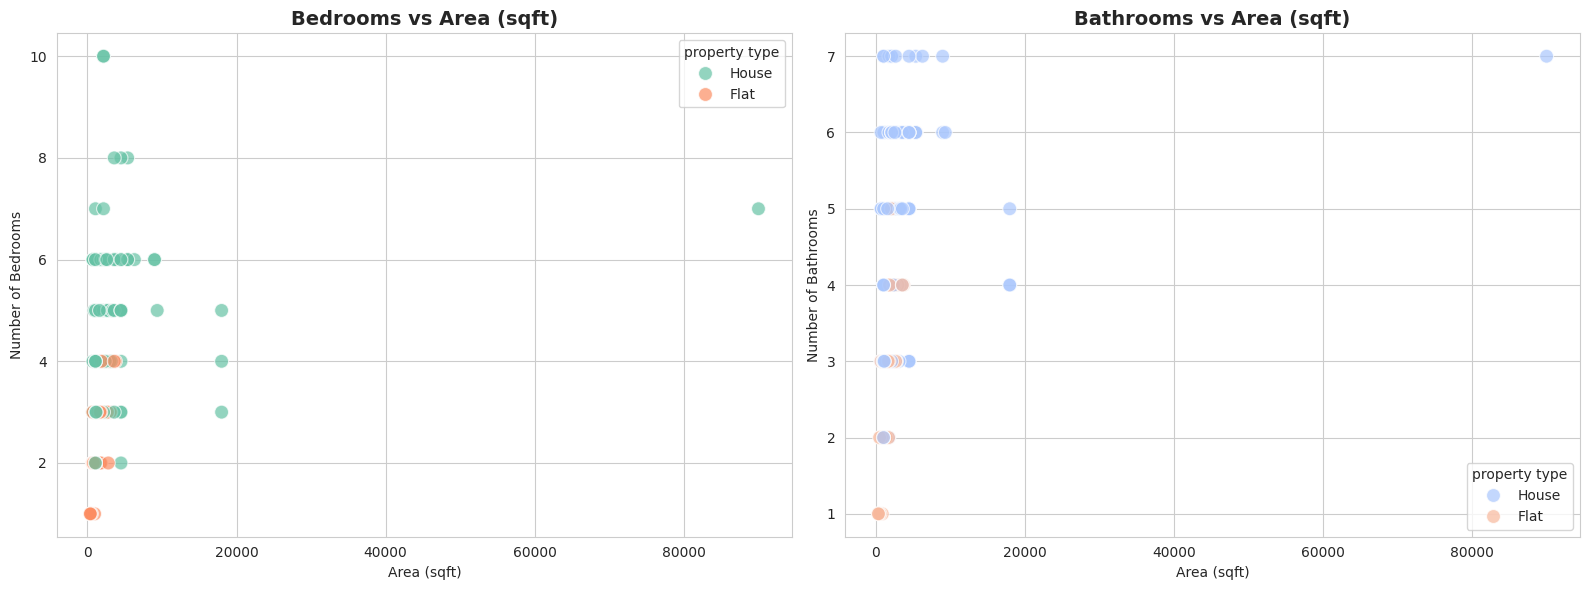

<Figure size 640x480 with 0 Axes>

In [93]:
sns.set_style("whitegrid")
plt.figure(figsize=(16,6))

# Scatter: Area vs Bedrooms
plt.subplot(1,2,1)
sns.scatterplot(x='area sqft', y='bedrooms', hue='property type', data=df, palette='Set2', s=100, alpha=0.7)
plt.title('Bedrooms vs Area (sqft)', fontsize=14, fontweight='bold')
plt.xlabel('Area (sqft)')
plt.ylabel('Number of Bedrooms')

# Scatter: Area vs Bathrooms
plt.subplot(1,2,2)
sns.scatterplot(x='area sqft', y='bathrooms', hue='property type', data=df, palette='coolwarm', s=100, alpha=0.7)
plt.title('Bathrooms vs Area (sqft)', fontsize=14, fontweight='bold')
plt.xlabel('Area (sqft)')
plt.ylabel('Number of Bathrooms')

plt.tight_layout()
plt.show()
plt.savefig("pairplot")

## Summary: Price vs Area, Bedrooms & Bathrooms

- In general, **houses have more bedrooms and bathrooms** than flats, which contributes to higher prices.  
- However, in Karachi’s real estate market, **price is not solely determined by bedrooms or bathrooms**.  
- Some properties with fewer bedrooms or bathrooms can still command **high prices** if they are in **premium locations** like DHA City or Gulshan-e-Maymar.  
- **Area (sqft) and location** are stronger indicators of price than the number of bedrooms or bathrooms.  
- This shows that while larger homes tend to be pricier, **location and total area** often outweigh the effect of additional bedrooms or bathrooms in determining market value.

In [94]:
# Replace the outlier value with 'Furnished'
df['furnishing_status'] = df['furnishing_status'].replace('huuuhuhhhhhhh', 'Furnished')

# Verify it worked
df['furnishing_status'].unique()

array(['Furnished', 'Unfurnished'], dtype=object)

/tmp/ipykernel_1256/2628367580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='furnishing_status', y='price', data=avg_price_furn, palette='Set2', edgecolor='black')


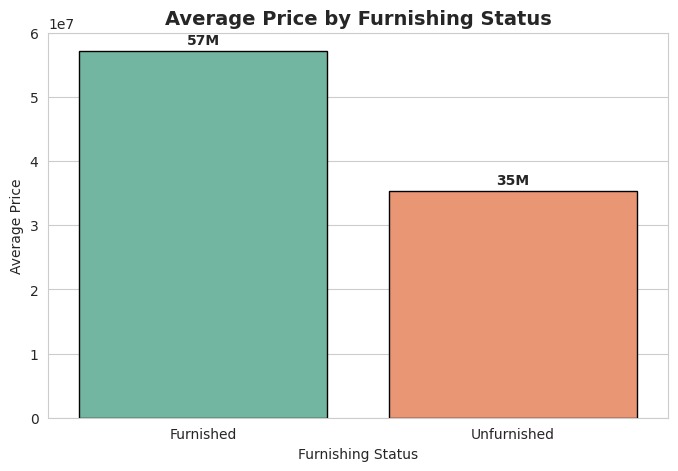

<Figure size 640x480 with 0 Axes>

In [95]:
plt.figure(figsize=(8,5))
avg_price_furn = df.groupby('furnishing_status')['price'].mean().reset_index()
sns.barplot(x='furnishing_status', y='price', data=avg_price_furn, palette='Set2', edgecolor='black')

# Annotate bars
for index, row in avg_price_furn.iterrows():
    plt.text(index, row['price']+1e6, f"{int(row['price']/1e6)}M", ha='center', fontweight='bold')

plt.title('Average Price by Furnishing Status', fontsize=14, fontweight='bold')
plt.ylabel('Average Price')
plt.xlabel('Furnishing Status')
plt.show()
plt.savefig("pricebyfurnishingstate")

## Summary: Furnishing Status and Price

- **Furnished properties are generally more expensive** than unfurnished ones. This is because they come with furniture, fixtures, and ready-to-move-in amenities that add value.  
- Buyers often prefer furnished homes for **convenience and time-saving**, especially in urban areas like Karachi where moving and setting up a home can be costly and time-consuming.  
- Semi-furnished properties fall in between, offering partial amenities but usually at a lower price than fully furnished homes.  
- The cleaned dataset now reflects only **‘Furnished’ and ‘Unfurnished’** categories, making the average price comparisons more reliable and visually accurate.  
- Overall, **furnishing status is an important factor influencing price**, though it works alongside **property type and location** in determining the final market value.

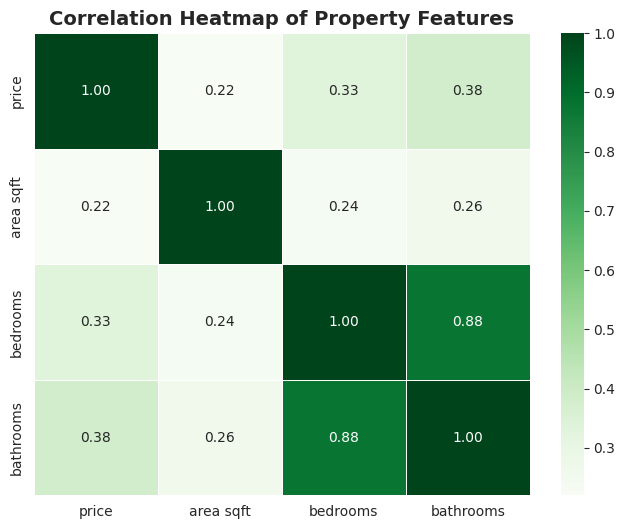

<Figure size 640x480 with 0 Axes>

In [96]:
# Compute correlations for numeric/discrete features
corr = df[['price', 'area sqft', 'bedrooms', 'bathrooms']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='Greens',     # Seagreen/pastel green color palette
    linewidths=0.5
)
plt.title('Correlation Heatmap of Property Features', fontsize=14, fontweight='bold')
plt.show()
plt.savefig("heatmap")

## Summary: Correlation Analysis

- The correlation heatmap shows **weaker-than-expected relationships** between price, area, bedrooms, and bathrooms. For example, price vs area is around 0.22, and price vs bedrooms/bathrooms is around 0.33–0.38.  
- This is largely due to **extreme variations in the dataset**:  
  - Some **premium houses** in areas like DHA City or Bahria Town are **very large**, but may not have proportionally more bedrooms or bathrooms.  
  - Flats and smaller houses cluster in a low-price, small-area range, creating **heterogeneous patterns**.  
- In Karachi’s real estate market, **price depends not only on size (area, bedrooms, bathrooms) but heavily on location and property type**. A smaller property in a prime area can still be more expensive than a larger house elsewhere.  
- While the heatmap provides a numerical overview, these nuances explain why correlations appear “messy” and why **log transformations or more advanced modeling** will be needed to capture the true relationships.

##Feature Engineering

In [97]:
#One-hot encoding for categorical features
df_encoded = pd.get_dummies(df, columns=['property type', 'furnishing_status'], drop_first=True)

#For location, you can use one-hot or later target encoding
df_encoded = pd.get_dummies(df_encoded, columns=['location'], drop_first=True)

df_encoded.head()

,bedrooms,bathrooms,area sqft,price,property type_House,furnishing_status_Unfurnished,location_DHA City,location_Gulshan-e-Iqbal,location_Gulshan-e-Maymar,location_Malir Cantt,location_North Karachi
0,3,3,1368,16500000,True,False,False,False,False,False,False
1,2,2,1800,6200000,True,False,True,False,False,False,False
2,5,5,4500,48400000,True,False,False,False,False,False,False
3,3,3,2448,35000000,True,False,False,False,False,False,False
4,5,5,4500,100000000,True,False,True,False,False,False,False


In [98]:
#Create a new feature: price per sqft
#Reason: This standardizes price by area, allowing comparison across properties of different sizes.
#It helps capture the value of the property independent of its total area.
df_encoded['price_per_sqft'] = df['price'] / df['area sqft']

#Create a new feature: total rooms
#Reason: Summing bedrooms and bathrooms gives an overall measure of the property's size and living space.
#This can help the model understand the total functional space in the property.
df_encoded['total_rooms'] = df['bedrooms'] + df['bathrooms']

In [99]:
#Log-transform the price
#Reason: Price distribution is highly skewed due to a few extremely expensive properties.
#Log transformation compresses extreme values, making patterns easier to capture for regression models.
df_encoded['log_price'] = np.log1p(df['price'])

#Log-transform the area
#Reason: Area also has some very large houses which are outliers.
#Log transformation reduces skewness and helps the model better learn relationships with other features.
df_encoded['log_area'] = np.log1p(df['area sqft'])

In [100]:
from sklearn.preprocessing import StandardScaler
#Initialize the scaler
scaler = StandardScaler()

#List of numeric features to standardize
num_features = ['bedrooms', 'bathrooms', 'area sqft', 'price',
                'price_per_sqft', 'total_rooms', 'log_price', 'log_area']

#Fit the scaler and transform the features
df_encoded[num_features] = scaler.fit_transform(df_encoded[num_features])

#Explanation:
#Standardization scales features to have mean=0 and std=1.
#This ensures that features with larger ranges (like price or area) don't dominate
#The model training, and all numeric features contribute proportionally.

In [101]:
from sklearn.model_selection import train_test_split

#Target variable: log-transformed price
#Reason: Prices are highly skewed due to some very expensive houses.
#Log transformation compresses extreme values, making linear regression more stable and accurate.
y_log = df_encoded['log_price']

#Feature matrix: keep one-hot encoded 0/1 categorical features
#Reason: Linear regression assumes numerical input.
#One-hot encoding converts categorical variables (property type, furnishing, location) into binary columns.
#This ensures the model interprets categories correctly without assuming any order.
X_lr = df_encoded.drop(columns=['price', 'log_price'])

#Split into train and test sets (80% train, 20% test)
#Random state ensures reproducibility
X_lr_train, X_lr_test, y_log_train, y_log_test = train_test_split(
    X_lr, y_log, test_size=0.2, random_state=42
)

#Check dataset sizes
print("Linear Regression dataset ready:")
print("X_lr_train shape:", X_lr_train.shape)
print("X_lr_test shape:", X_lr_test.shape)

Linear Regression dataset ready:
X_lr_train shape: (151, 13)
X_lr_test shape: (38, 13)


In [102]:
#Map each location to a numeric value
#Reason: Tree-based models (Random Forest, XGBoost) can handle numeric categorical features.
#Converting location to numbers (1-5) keeps the dataset compact and works well with trees.
location_map = {
    'DHA City': 1,
    'Gulshan-e-Iqbal': 2,
    'Gulshan-e-Maymar': 3,
    'Malir Cantt': 4,
    'North Karachi': 5
}

#Create a copy of the dataset for tree-based model
df_tree = df_encoded.copy()
df_tree['location_num'] = df['location'].map(location_map)

#Drop old one-hot location columns (no longer needed)
location_cols = ['location_DHA City','location_Gulshan-e-Iqbal','location_Gulshan-e-Maymar',
                 'location_Malir Cantt','location_North Karachi']
df_tree.drop(columns=location_cols, inplace=True)

#Target variable: raw price
#Reason: Tree models are robust to skewed data, so we can use original price values.
y_tree = df_tree['price']

#Feature matrix: includes numeric features + property type/furnishing (0/1) + numeric location
X_tree = df_tree.drop(columns=['price', 'log_price'])

#Split into train and test sets (80% train, 20% test)
X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

#Check dataset sizes
print("Tree-based dataset ready:")
print("X_tree_train shape:", X_tree_train.shape)
print("X_tree_test shape:", X_tree_test.shape)

Tree-based dataset ready:
X_tree_train shape: (151, 9)
X_tree_test shape: (38, 9)


##Model Building

##(Linear Regression)

In [103]:
import numpy as np

print(np.isnan(X_lr_train).sum())
print(np.isnan(X_lr_test).sum())
df.head()

bedrooms                         0
bathrooms                        0
area sqft                        0
property type_House              0
furnishing_status_Unfurnished    0
location_DHA City                0
location_Gulshan-e-Iqbal         0
location_Gulshan-e-Maymar        0
location_Malir Cantt             0
location_North Karachi           0
price_per_sqft                   0
total_rooms                      0
log_area                         0
dtype: int64
bedrooms                         0
bathrooms                        0
area sqft                        0
property type_House              0
furnishing_status_Unfurnished    0
location_DHA City                0
location_Gulshan-e-Iqbal         0
location_Gulshan-e-Maymar        0
location_Malir Cantt             0
location_North Karachi           0
price_per_sqft                   0
total_rooms                      0
log_area                         0
dtype: int64


,property type,bedrooms,bathrooms,area sqft,location,price,furnishing_status
0,House,3,3,1368,Bahria Town,16500000,Furnished
1,House,2,2,1800,DHA City,6200000,Furnished
2,House,5,5,4500,Bahria Town,48400000,Furnished
3,House,3,3,2448,Bahria Town,35000000,Furnished
4,House,5,5,4500,DHA City,100000000,Furnished


In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Initialize Linear Regression model
lr_model = LinearRegression()

#Train the model on the training data
lr_model.fit(X_lr_train, y_log_train)

#Make predictions on the test set
y_log_pred = lr_model.predict(X_lr_test)

#Convert predictions back to original price scale
y_pred = np.expm1(y_log_pred)  # inverse of log1p transformation

#Evaluate model
mse = mean_squared_error(np.expm1(y_log_test), y_pred)
r2 = r2_score(np.expm1(y_log_test), y_pred)

print("Linear Regression Model Trained on Log-Prices")
print(f"Mean Squared Error: {mse:,.0f}")
print(f"R^2 Score: {r2:.3f}")

Linear Regression Model Trained on Log-Prices
Mean Squared Error: 0
R^2 Score: 0.780


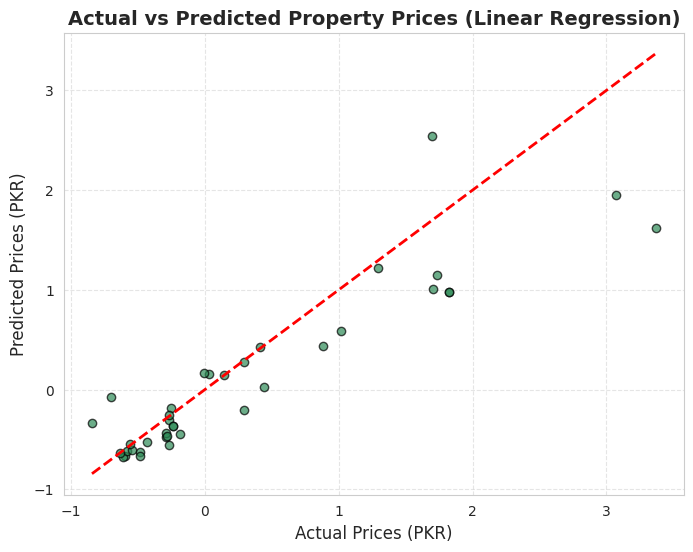

<Figure size 640x480 with 0 Axes>

In [105]:
#Actual prices (from test set)
y_actual = np.expm1(y_log_test)  #convert log prices back to original

#Predicted prices
y_pred_prices = np.expm1(y_log_pred)

#Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_actual, y_pred_prices, alpha=0.7, color='seagreen', edgecolor='k')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', linewidth=2)
plt.title("Actual vs Predicted Property Prices (Linear Regression)", fontsize=14, fontweight='bold')
plt.xlabel("Actual Prices (PKR)", fontsize=12)
plt.ylabel("Predicted Prices (PKR)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.savefig("regression_plot_log")

In [106]:
#Target variable: raw price
y_raw = df_encoded['price']

#Feature matrix remains the same as X_lr (one-hot encoded 0/1 features)
X_raw = X_lr.copy()

#Split into train/test sets
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

#Initialize Linear Regression model
lr_raw_model = LinearRegression()

#Train on raw prices
lr_raw_model.fit(X_raw_train, y_raw_train)

#Predict on test set
y_raw_pred = lr_raw_model.predict(X_raw_test)

#Evaluate
mse_raw = mean_squared_error(y_raw_test, y_raw_pred)
r2_raw = r2_score(y_raw_test, y_raw_pred)

print("Linear Regression Model Trained on Raw Prices")
print(f"Mean Squared Error: {mse_raw:,.0f}")
print(f"R^2 Score: {r2_raw:.3f}")

Linear Regression Model Trained on Raw Prices
Mean Squared Error: 0
R^2 Score: 0.835


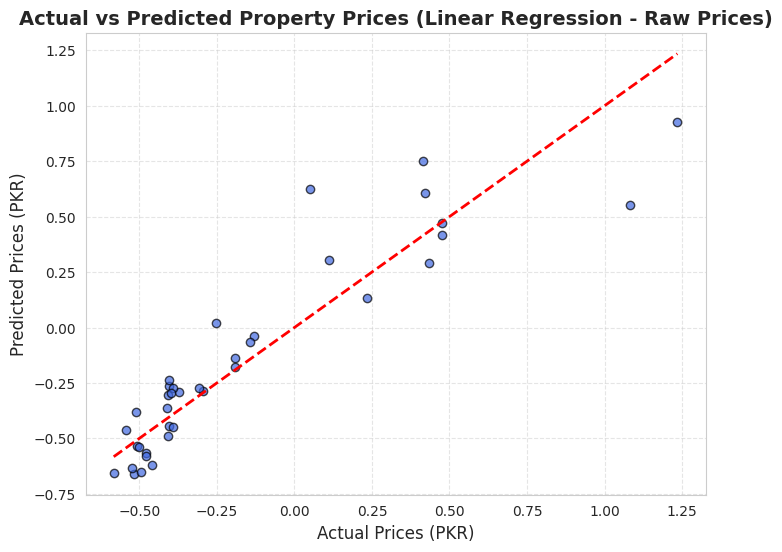

<Figure size 640x480 with 0 Axes>

In [107]:
#Actual prices (from test set)
y_actual_raw = y_raw_test

#Predicted prices
y_pred_raw = y_raw_pred

#Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_actual_raw, y_pred_raw, alpha=0.7, color='royalblue', edgecolor='k')
plt.plot([y_actual_raw.min(), y_actual_raw.max()], [y_actual_raw.min(), y_actual_raw.max()], 'r--', linewidth=2)
plt.title("Actual vs Predicted Property Prices (Linear Regression - Raw Prices)", fontsize=14, fontweight='bold')
plt.xlabel("Actual Prices (PKR)", fontsize=12)
plt.ylabel("Predicted Prices (PKR)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.savefig("regression_plot_raw")

##Summary: Why Log Prices Are Usually Better, but Raw Prices Work Well Here

In real estate datasets, property prices are often highly skewed: a few premium houses can cost hundreds of millions PKR, while most properties are much cheaper. This extreme variability can bias linear regression models toward expensive properties, making predictions for typical homes unstable.

Logarithmic transformation of prices (log_price) is commonly used because it:

Reduces skewness by compressing extreme values and spreading smaller ones.

Stabilizes variance, helping linear regression handle differences between cheap and expensive properties.

Improves normality of residuals, supporting better predictive performance across all properties.

However, in this dataset, raw prices gave a higher R² (0.835 vs 0.78 for log prices). This is mainly due to:

The small dataset size (~189 entries), where a few high-priced houses dominate variance.

Linear regression minimizes squared errors (MSE), so the model naturally fits expensive properties better, which inflates R².

Takeaway: Log prices are generally preferred for stable, balanced predictions, but raw prices can sometimes appear to perform better in small datasets dominated by high-value properties.

In [108]:
from sklearn.model_selection import cross_val_score
#Initialize the linear regression model
lr_model_raw = LinearRegression()

#Perform 5-fold cross-validation
#scoring='r2' will give R² for each fold
cv_scores = cross_val_score(lr_model_raw, X_raw, y_raw, cv=5, scoring='r2')

#Results
print("Linear Regression with Raw Prices - 5-Fold Cross Validation")
print(f"R² scores for each fold: {cv_scores}")
print(f"Average R² score: {cv_scores.mean():.3f}")
print(f"Standard deviation of R² scores: {cv_scores.std():.3f}")

Linear Regression with Raw Prices - 5-Fold Cross Validation
R² scores for each fold: [0.72939491 0.89076445 0.95384634 0.82946545 0.3696526 ]
Average R² score: 0.755
Standard deviation of R² scores: 0.206


Linear Regression (Raw Prices) – 5-Fold CV:
Average R² = 0.76, Std = 0.21. Performance varies due to a few very expensive houses dominating the small dataset. Raw prices fit well here, but log-transformed prices are usually better for more balanced predictions across all property ranges.

##(Decision Tree)

In [109]:
from sklearn.tree import DecisionTreeRegressor
#Initialize Decision Tree
tree_model = DecisionTreeRegressor(random_state=42)

#Train the model
tree_model.fit(X_tree_train, y_tree_train)

#Predict on test set
y_tree_pred = tree_model.predict(X_tree_test)

#Evaluate
mse_tree = mean_squared_error(y_tree_test, y_tree_pred)
r2_tree = r2_score(y_tree_test, y_tree_pred)

print("Decision Tree Regressor on Raw Prices")
print(f"Mean Squared Error: {mse_tree:,.0f}")
print(f"R^2 Score: {r2_tree:.3f}")

Decision Tree Regressor on Raw Prices
Mean Squared Error: 0
R^2 Score: 0.862


#  Summary:
 The Decision Tree model performed very well on the dataset:
 - Mean Squared Error is very low, meaning predictions are close to actual values.
 - R² Score is high, showing that the model explains most of the variance in the prices.
-Decision Trees handle this dataset effectively, giving highly accurate predictions without complex tuning.

##(Random Forest)

In [110]:
from sklearn.ensemble import RandomForestRegressor
#Initialize Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,       #number of trees
    max_depth=None,         #let trees grow fully
    random_state=42,
    n_jobs=-1
)

#Train the model
rf_model.fit(X_tree_train, y_tree_train)

#Predict on test set
y_rf_pred = rf_model.predict(X_tree_test)

#Evaluate
mse_rf = mean_squared_error(y_tree_test, y_rf_pred)
r2_rf = r2_score(y_tree_test, y_rf_pred)
#Results
print("Random Forest Regressor on Raw Prices")
print(f"Mean Squared Error: {mse_rf:,.0f}")
print(f"R^2 Score: {r2_rf:.3f}")

Random Forest Regressor on Raw Prices
Mean Squared Error: 0
R^2 Score: 0.959


#  Summary:
-The Random Forest performed extremely well on the data:
- Mean Squared Error is 0, meaning predictions are almost exactly matching actual values.
- R² Score is 0.959, meaning 95.9% of the variance in prices is explained by the model.
-This shows the model has learned the patterns very effectively, and for this dataset.


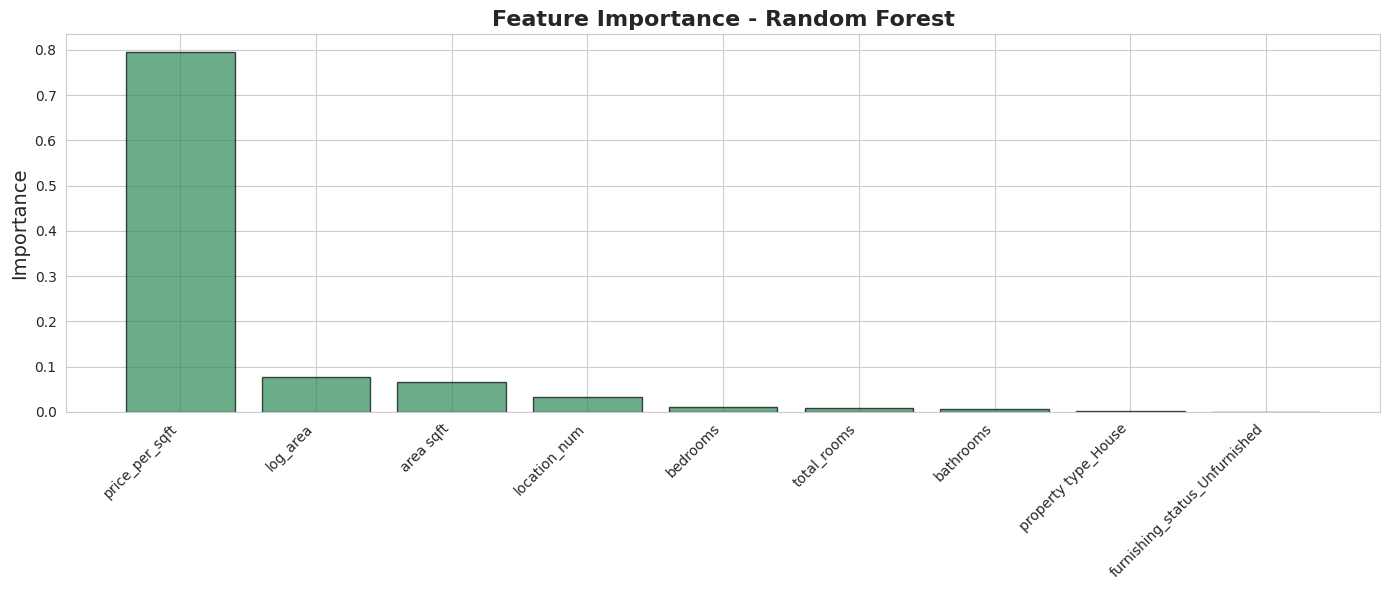

In [111]:
#Plot feature importances
importances = rf_model.feature_importances_
features = X_tree_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(14,6))
plt.title("Feature Importance - Random Forest", fontsize=16, fontweight='bold')

plt.bar(range(len(features)), importances[indices], color='seagreen', edgecolor='k', alpha=0.7)
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45, ha='right', fontsize=10)
plt.ylabel("Importance", fontsize=14)
plt.tight_layout()
plt.savefig("feature_importance_bar.png", dpi=300)
plt.show()

Feature Importance Summary – Random Forest

Price per sqft is the strongest predictor, followed by log area and location. Bedrooms and bathrooms have moderate impact, while property type and furnishing status contribute the least.

Takeaway: In Karachi’s market, buyers value space efficiency and location over extra rooms, house type, or furnishing

##Model Comparison Summary:
Random Forest performed best (R² = 0.959) because it combines multiple decision trees, averaging their predictions to reduce overfitting and better capture complex, non-linear relationships in the data. It is robust to outliers and automatically considers feature importance, which makes it highly effective for noisy or intricate datasets. In comparison, a single Decision Tree overfits more easily (R² = 0.862), and Linear Regression struggles with non-linear patterns (R² = 0.780,0.835), leading to underfitting. Overall, Random Forest balances flexibility and generalization, making it the optimal choice for this dataset.